In [10]:
!pip -q install huggingface_hub
from huggingface_hub import snapshot_download
import zipfile, os, glob

ROOT = snapshot_download("BoKelvin/SLAKE", repo_type="dataset", local_dir="/content/slake")
for z in ["imgs.zip", "KG.zip"]:
    with zipfile.ZipFile(f"{ROOT}/{z}") as f:
        f.extractall(ROOT)

# locate the image root regardless of how the zip nests folders
IMG_DIR = os.path.dirname(glob.glob(f"{ROOT}/**/xmlab1", recursive=True)[0])
print("IMG_DIR:", IMG_DIR, "| image folders:", len(os.listdir(IMG_DIR)))

Reconstructing (incomplete total...): |          |  0.00B /  0.00B            

Fetching 8 files:   0%|          | 0/8 [00:00<?, ?it/s]

IMG_DIR: /content/slake/imgs | image folders: 643


In [11]:
import pandas as pd, json, re
import numpy as np

splits = {s: pd.read_json(f"{ROOT}/{s}.json") for s in ["train", "validation", "test"]}
for s, df in splits.items():
    print(f"{s:10s} rows={len(df):5d}  langs={df.q_lang.value_counts().to_dict()}")

en = {s: df[df.q_lang == "en"].reset_index(drop=True) for s, df in splits.items()}
print({s: len(d) for s, d in en.items()})
en["train"].head(3)

train      rows= 9835  langs={'en': 4919, 'zh': 4916}
validation rows= 2099  langs={'en': 1053, 'zh': 1046}
test       rows= 2094  langs={'en': 1061, 'zh': 1033}
{'train': 4919, 'validation': 1053, 'test': 1061}


,img_id,img_name,question,answer,q_lang,location,modality,answer_type,base_type,content_type,triple,qid
0,1,xmlab1/source.jpg,What modality is used to take this image?,MRI,en,Abdomen,MRI,OPEN,vqa,Modality,"[vhead, _, _]",0
1,1,xmlab1/source.jpg,Which part of the body does this image belong to?,Abdomen,en,Abdomen,MRI,OPEN,vqa,Position,"[vhead, _, _]",1
2,1,xmlab1/source.jpg,What is the mr weighting in this image?,T2,en,Abdomen,MRI,OPEN,vqa,Modality,"[vhead, _, _]",2


In [12]:
# rows = category, columns = split
for col in ["answer_type", "content_type", "modality", "location"]:
    tbl = pd.concat({s: d[col].value_counts() for s, d in en.items()}, axis=1).fillna(0).astype(int)
    print(f"--- {col} ---\n{tbl}\n")

--- answer_type ---
             train  validation  test
answer_type                         
OPEN          2976         631   645
CLOSED        1943         422   416

--- content_type ---
              train  validation  test
content_type                         
Organ          1269         254   253
Position        847         183   186
Abnormality     716         132   150
KG              582         155   148
Modality        534         110   108
Size            323          59    65
Plane           249          62    58
Quantity        220          56    52
Color           137          31    34
Shape            42          11     7

--- modality ---
          train  validation  test
modality                         
CT         2367         482   472
X-Ray      1423         338   361
MRI        1129         233   228

--- location ---
                   train  validation  test
location                                  
Lung                1710         386   419
Abdomen            

In [13]:
norm = lambda a: str(a).strip().lower()

imgs = {s: set(d.img_id) for s, d in en.items()}
print("unique images:", {s: len(v) for s, v in imgs.items()})
print("image overlap  train∩test:", len(imgs["train"] & imgs["test"]),
      "| train∩val:", len(imgs["train"] & imgs["validation"]))   # should be 0

train_ans = set(en["train"].answer.map(norm))
t = en["test"]
for at in ["CLOSED", "OPEN"]:
    sub = t[t.answer_type == at]
    seen = sub.answer.map(norm).isin(train_ans).mean()          # low % = open answers are hard for any classifier
    print(f"{at:6s} n={len(sub):4d}  unique answers={sub.answer.map(norm).nunique():3d}  answer seen in train={seen:.1%}")

print("\nTop CLOSED answers (not all yes/no):\n", t[t.answer_type == "CLOSED"].answer.map(norm).value_counts().head(8))

unique images: {'train': 450, 'validation': 96, 'test': 96}
image overlap  train∩test: 0 | train∩val: 0
CLOSED n= 416  unique answers= 20  answer seen in train=100.0%
OPEN   n= 645  unique answers=128  answer seen in train=99.7%

Top CLOSED answers (not all yes/no):
 answer
no        180
yes       175
lung       12
liver       9
t2          7
heart       5
right       4
spleen      3
Name: count, dtype: int64


In [14]:
from PIL import Image

ex = f"{IMG_DIR}/xmlab1"
print("files:", os.listdir(ex))
print("\nmask.txt:\n", open(f"{ROOT}/mask.txt").read())
print("detection.json:", json.load(open(f"{ex}/detection.json")))

mask_path = glob.glob(f"{ex}/mask*.png")[0]
m = np.array(Image.open(mask_path))
src = Image.open(f"{ex}/source.jpg")
print(f"\nimage {src.size} {src.mode} | mask {m.shape} {m.dtype} | unique pixel values: {np.unique(m)}")

files: ['mask.png', 'detection.json', 'question.json', 'source.jpg']

mask.txt:
 30:Left Humerus Head
35:Right Humerus Head
40:Larynx
45:Right Femoral Head
50:Left Femoral Head
55:Brain Stem
60:Duodenum
65:Tooth
70:Liver
75:Trachea
80:Left Eye
90:Right Eye
95:Brain Edema
105:Rectum
110:Esophagus
120:Left Ear
125:Bladder
130:Right Ear
135:Left Kidney
140:Brain Non-enhancing Tumor
145:Spinal Cord
150:Kidney Cancer
155:Right Kidney
160:Left Temporal Lobe
165:Stomach
170:Right Temporal Lobe
175:Liver Cancer
180:Heart
185:Brain Enhancing Tumor
200:Left Mandible
205:Small Bowel
210:Right Mandible
215:Left Lung
225:Right Lung
230:Spleen
235:Colon
240:Left Parotid
245:Lung Cancer
250:Right Parotid
detection.json: [{'Liver': [54.0, 106.0, 30.0, 31.0]}]

image (256, 256) RGB | mask (256, 256, 4) uint8 | unique pixel values: [  0  70 255]


{30: 'Left Humerus Head', 35: 'Right Humerus Head', 40: 'Larynx', 45: 'Right Femoral Head', 50: 'Left Femoral Head', 55: 'Brain Stem', 60: 'Duodenum', 65: 'Tooth', 70: 'Liver', 75: 'Trachea', 80: 'Left Eye', 90: 'Right Eye', 95: 'Brain Edema', 105: 'Rectum', 110: 'Esophagus', 120: 'Left Ear', 125: 'Bladder', 130: 'Right Ear', 135: 'Left Kidney', 140: 'Brain Non-enhancing Tumor', 145: 'Spinal Cord', 150: 'Kidney Cancer', 155: 'Right Kidney', 160: 'Left Temporal Lobe', 165: 'Stomach', 170: 'Right Temporal Lobe', 175: 'Liver Cancer', 180: 'Heart', 185: 'Brain Enhancing Tumor', 200: 'Left Mandible', 205: 'Small Bowel', 210: 'Right Mandible', 215: 'Left Lung', 225: 'Right Lung', 230: 'Spleen', 235: 'Colon', 240: 'Left Parotid', 245: 'Lung Cancer', 250: 'Right Parotid'}


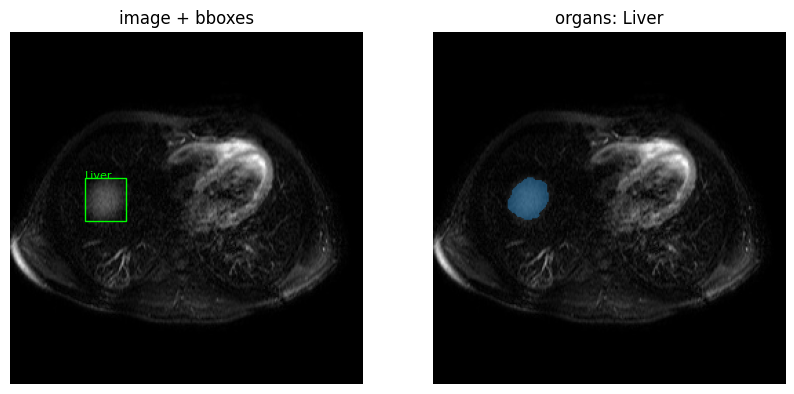

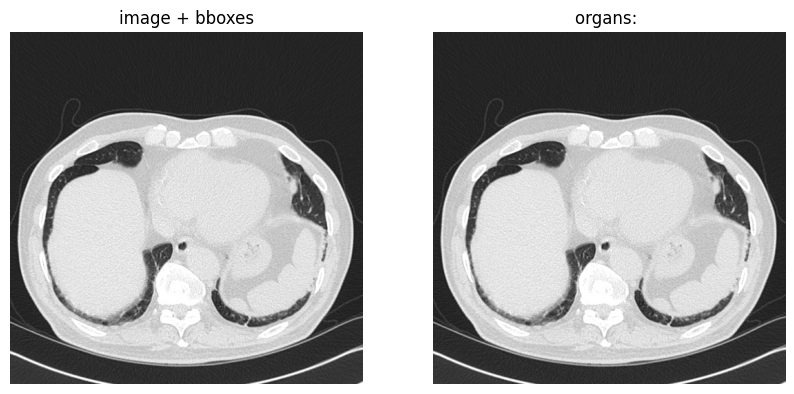

In [15]:
import matplotlib.pyplot as plt, matplotlib.patches as patches

# mask.txt maps pixel value <-> organ; parse either "70: Liver" or "Liver: 70" style
legend = {}
for chunk in re.split(r"[,\n;]", open(f"{ROOT}/mask.txt").read()):
    nums = re.findall(r"\d+", chunk)
    name = re.sub(r"[\d:：]", "", chunk).strip()
    if nums and name:
        legend[int(nums[0])] = name
print(legend)

def load_mask(folder):
    m = np.array(Image.open(glob.glob(f"{folder}/mask*.png")[0]))
    return m[..., 0] if m.ndim == 3 else m      # collapse RGB masks to one channel

def show(img_folder_name):
    folder = f"{IMG_DIR}/{img_folder_name}"
    img, m = Image.open(f"{folder}/source.jpg").convert("RGB"), load_mask(folder)
    det = json.load(open(f"{folder}/detection.json"))
    fig, ax = plt.subplots(1, 2, figsize=(10, 5))
    ax[0].imshow(img); ax[0].set_title("image + bboxes")
    for d in det:                                # assumed [x, y, w, h]; if boxes look off it's [x1, y1, x2, y2]
        for organ, (x, y, w, h) in d.items():
            ax[0].add_patch(patches.Rectangle((x, y), w, h, fill=False, color="lime"))
            ax[0].text(x, y, organ, color="lime", fontsize=8)
    ax[1].imshow(img); ax[1].imshow(np.ma.masked_equal(m, 0), alpha=0.5, cmap="tab20")
    ax[1].set_title("organs: " + ", ".join(legend.get(v, str(v)) for v in np.unique(m) if v))
    for a in ax: a.axis("off")
    plt.show()

show("xmlab1"); show("xmlab100")

In [16]:
# Cell 6b: verify bbox format against the masks across the whole dataset
raw = np.array(Image.open(glob.glob(f"{IMG_DIR}/xmlab1/mask*.png")[0]))
print("xmlab1 unique values per channel:", [np.unique(raw[..., c]).tolist() for c in range(raw.shape[2])])

name2val = {v.lower(): k for k, v in legend.items()}   # "liver" -> 70

def area(b):
    return max(0, b[2] - b[0]) * max(0, b[3] - b[1])

def box_iou(a, b):                                       # boxes as (x1, y1, x2, y2)
    inter = area((max(a[0], b[0]), max(a[1], b[1]), min(a[2], b[2]), min(a[3], b[3])))
    union = area(a) + area(b) - inter
    return inter / union if union else 0.0

rows = []
for folder in glob.glob(f"{IMG_DIR}/xmlab*"):
    if not glob.glob(f"{folder}/mask*.png"):
        continue
    m = load_mask(folder)
    for d in json.load(open(f"{folder}/detection.json")):
        for organ, (a, b, c, e) in d.items():
            val = name2val.get(organ.lower())
            if val is None or not (m == val).any():
                continue
            ys, xs = np.where(m == val)
            mask_box = (xs.min(), ys.min(), xs.max() + 1, ys.max() + 1)
            rows.append({"organ": organ,
                         "iou_if_xywh": box_iou(mask_box, (a, b, a + c, b + e)),
                         "iou_if_xyxy": box_iou(mask_box, (a, b, c, e))})

chk = pd.DataFrame(rows)
print(f"{len(chk)} boxes matched to mask regions")
print(chk[["iou_if_xywh", "iou_if_xyxy"]].describe().loc[["mean", "50%", "min"]])

xmlab1 unique values per channel: [[0, 70], [0, 70], [0, 70], [255]]
1430 boxes matched to mask regions
      iou_if_xywh  iou_if_xyxy
mean     0.779706     0.010341
50%      1.000000     0.000000
min      0.001243     0.000000


In [17]:
# Cell 6c: annotation coverage per split
def n_boxes(folder):
    return sum(len(d) for d in json.load(open(f"{folder}/detection.json")))

def n_mask_regions(folder):
    if not glob.glob(f"{folder}/mask*.png"):
        return 0
    return sum(1 for v in np.unique(load_mask(folder)) if v in legend)

for s, d in en.items():
    folders = {f"{IMG_DIR}/{os.path.dirname(n)}" for n in d.img_name.unique()}
    nb = [n_boxes(f) for f in folders]
    nm = [n_mask_regions(f) for f in folders]
    print(f"{s:10s} images={len(folders):3d} | with boxes={sum(b > 0 for b in nb):3d} | with mask regions={sum(m > 0 for m in nm):3d}")

train      images=450 | with boxes=405 | with mask regions=406
validation images= 96 | with boxes= 88 | with mask regions= 88
test       images= 96 | with boxes= 87 | with mask regions= 87


In [18]:
# Cell 7 (replaces old): map each test question to the annotated region(s) it refers to
COMPARE = re.compile(r"\b(which is|bigger|smaller|biggest|smallest|larger|largest)\b|,.*\bor\b")

def boxes_in(img_name):
    folder = f"{IMG_DIR}/{os.path.dirname(img_name)}"
    out = {}
    for d in json.load(open(f"{folder}/detection.json")):
        for k, v in d.items():
            out.setdefault(k.lower(), []).append(v)
    return out

def target_region(row):
    q = row.question.lower()
    if COMPARE.search(q):                                  # comparisons -> skip
        return None
    boxes = boxes_in(row.img_name)
    exact = [k for k in boxes if re.search(rf"\b{re.escape(k)}s?\b", q)]
    exact = [k for k in exact if not any(k != o and k in o for o in exact)]   # keep most specific
    if len(exact) == 1:
        return (exact[0],)
    if len(exact) > 1:
        return None
    parents = tuple(sorted(k for k in boxes if re.search(rf"\b{re.escape(k.split()[-1])}s?\b", q)))
    return parents or None                                 # "lung" -> (left lung, right lung)

t = en["test"].copy()
t["target"] = t.apply(target_region, axis=1)
elig = t[t.target.notna()].copy()
elig["has_mask"] = elig.target.map(lambda ks: all(k in name2val for k in ks))

print(f"grounding-eligible test questions: {len(elig)} / {len(t)} ({len(elig)/len(t):.1%})")
print(f"  with pixel mask: {elig.has_mask.sum()} | box only: {(~elig.has_mask).sum()}\n")
print(elig.content_type.value_counts().to_string(), "\n")
print(elig.explode("target").target.value_counts().head(15).to_string(), "\n")
print(elig[["question", "answer", "target"]].sample(10, random_state=0).to_string())

grounding-eligible test questions: 125 / 1061 (11.8%)
  with pixel mask: 93 | box only: 32

content_type
Position       43
Organ          33
Abnormality    25
Color          13
Shape           6
Quantity        5 

target
liver                        25
spleen                        9
brain non-enhancing tumor     9
pneumonia                     8
brain enhancing tumor         7
nodule                        6
pneumothorax                  6
spinal cord                   5
left kidney                   4
effusion                      4
atelectasis                   4
colon                         4
left lung                     4
right lung                    4
esophagus                     3 

                                                             question           answer                                              target
129                                      Does the liver look normal ?              Yes                                            (liver,)
484               

In [19]:
from google.colab import drive
drive.mount("/content/drive")
os.makedirs("/content/drive/MyDrive/medex_v2", exist_ok=True)

summary = {
    "slake_en_rows": {s: len(d) for s, d in en.items()},
    "slake_en_images": {s: len(v) for s, v in imgs.items()},
    "test_answer_type": en["test"].answer_type.value_counts().to_dict(),
    "test_grounding_eligible": int(len(elig)),
    "test_grounding_with_mask": int(elig.has_mask.sum()),
}
json.dump(summary, open("/content/drive/MyDrive/medex_v2/metrics.json", "w"), indent=2)
summary

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


{'slake_en_rows': {'train': 4919, 'validation': 1053, 'test': 1061},
 'slake_en_images': {'train': 450, 'validation': 96, 'test': 96},
 'test_answer_type': {'OPEN': 645, 'CLOSED': 416},
 'test_grounding_eligible': 125,
 'test_grounding_with_mask': 93}